## Introduzione

La seguente analisi è stata effettuata utilizzando un dataset che raccoglie i dati sui crimini registrati nella città di **Baltimora (Maryland, USA)**.
Il dataset contiene informazioni dettagliate su ogni evento criminale, tra cui **data, ora, tipologia di reato, localizzazione geografica, distretto di polizia e coordinate GPS**, coprendo un ampio periodo temporale.

L'obiettivo dell'analisi è quello di esplorare, pulire e comprendere l'andamento temporale e spaziale dei crimini, applicando tecniche di:
- **Classificazione**, per distinguere le varie tipologie di reato;
- **Regressione**, per stimare la frequenza o l'intensità dei crimini nel tempo;
- **Analisi di serie temporali e forecasting**, per prevedere l'evoluzione dei fenomeni criminali in determinati distretti o periodi.

Per l'analisi verranno utilizzate librerie Python come **pandas, matplotlib, seabord, statsmodels e scikit-learn**, che consentiranno di effettuare una **pulizia accurata dei dati, una analisi esplorativa (EDA) e la modellazione predittiva**.


In [14]:
import sys
import subprocess

# Installazione dei pacchetti necessari
subprocess.check_call([sys.executable, "-m", "pip", "install", "pandas", "numpy", "matplotlib", "seaborn", "scikit-learn", "tslearn", "statsmodels"])


0

### Import del dataset

Iniziamo l'analisi importanto il dataset in formato `.csv`, disponibile al seguente link ufficiale:
🔗 [City of Baltimore Crime Data](https://data.world/data-society/city-of-baltimore-crime-data)

Successivamente, verranno visualizzate le informazioni generali sulla struttura del dataset per comprenderne la composizione e la qualità dei dati disponibili.

In [26]:
import pandas as pd

file_path = 'CrimeData.csv'
crime_data = pd.read_csv(file_path)

# Mostra le informazioni di base del DataFrame
crime_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 285807 entries, 0 to 285806
Data columns (total 12 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   CrimeDate        285807 non-null  object 
 1   CrimeTime        285807 non-null  object 
 2   CrimeCode        285807 non-null  object 
 3   Location         284184 non-null  object 
 4   Description      285807 non-null  object 
 5   Inside/Outside   281611 non-null  object 
 6   Weapon           97396 non-null   object 
 7   Post             285616 non-null  float64
 8   District         285749 non-null  object 
 9   Neighborhood     284106 non-null  object 
 10  Location 1       284188 non-null  object 
 11  Total Incidents  285807 non-null  int64  
dtypes: float64(1), int64(1), object(10)
memory usage: 26.2+ MB


## Descrizione del dataset

Il dataset analizzato contiene **285.807 osservazioni** e **12 colonne**, ciascuna delle quali descrive un aspetto relativo a un singolo evento criminale registrato nella città di Baltimora.  
I dati coprono diverse dimensioni temporali, spaziali e categoriali, rendendoli adatti per analisi di tipo descrittivo, predittivo e temporale.

### Struttura delle colonne
| Colonna | Tipo | Descrizione |
|----------|------|-------------|
| **CrimeDate** | `object` | Data in cui il crimine è stato registrato. |
| **CrimeTime** | `object` | Ora dell’evento. |
| **CrimeCode** | `object` | Codice identificativo del tipo di reato. |
| **Location** | `object` | Indirizzo o descrizione del luogo in cui è avvenuto il crimine. Alcuni valori mancanti (≈0,6%). |
| **Description** | `object` | Descrizione testuale del tipo di crimine (es. “ROBBERY”, “ASSAULT”). |
| **Inside/Outside** | `object` | Indica se il crimine è avvenuto all’interno (“Inside”) o all’esterno (“Outside”). Alcuni valori mancanti (≈1,5%). |
| **Weapon** | `object` | Tipologia di arma utilizzata (es. “Firearm”, “Knife”). Alta percentuale di valori mancanti (~66%). |
| **Post** | `float64` | Numero del distretto di polizia (post) in cui è stato registrato il crimine. |
| **District** | `object` | Nome del distretto di polizia (es. “SOUTHERN”, “NORTHERN”). Pochi valori mancanti. |
| **Neighborhood** | `object` | Nome del quartiere di Baltimora in cui è avvenuto il crimine. Alcuni valori mancanti (≈0,6%). |
| **Location 1** | `object` | Coordinate geografiche (latitudine, longitudine) in formato stringa. |
| **Total Incidents** | `int64` | Numero totale di incidenti registrati per quella specifica voce (spesso pari a 1). |

### Considerazioni preliminari
Il dataset è **abbastanza completo**, con una percentuale di valori nulli limitata in quasi tutte le colonne tranne **Weapon**, che richiede attenzione nella fase di pulizia.  
I dati sono **prevalentemente categoriali e temporali**, il che li rende adatti per:  
- analisi di **frequenza dei crimini** per tipo, distretto o fascia oraria; 
- applicazione di **modelli di forecasting** sul numero di incidenti; 
- costruzione di **modelli di classificazione** basati su caratteristiche spaziali e temporali.

## Pulizia e preparazione dei dati

Per poter effettuare un'analisi efficace, sono necessarie alcune operazioni preliminari di **data cleaning** e **trasformazione**:

1. **Gestione dei valori mancanti**
   - Le colonne `Location`, `Inside/Outside`, `Weapon`, `District` e    `Neighborhood` presentano una certa quantità di valori nulli.
   - Si sostituiranno i valori con una categoria "Unknown".

2. **Creazione della colonna temporale unificata**
   - Le colonne `CrimeDate` e `CrimeTime` saranno unite in un'unica colonna `Datetime`:
     ```python
     crime_data['Datetime'] = pd.to_datetime(crime_data['CrimeDate'] + ' ' + crime_data['CrimeTime'], errors='coerce')
     ```

   - Questa nuova variabile temporale consentirà di:
     - ordinare gli eventi nel tempo (`sort_values('Datetime')`);
     - effettuare analisi stagionali o giornaliere;
     - eseguire resampling (su base giornaliera o settimanale).

3. **Rimozione o rinomina colonne non necessarie**
   - Le colonne ridondanti come `Location 1` (lat/lon) o poco informative saranno rimosse o riformattate.
   - Si estrarranno latitudine e longitudine da `Location 1` per analisi spaziali.

4. **Codifica delle variabili categoriali**
   - Per applicare algoritmi di classificazione o regressione, le colonne testuali (`Description`, `District`, `Inside/Outside`, ecc.) dovranno essere convertite in numeriche:
     - tramite **Label Encoding** o **One-hot Encoding**;

5. **Analisi temporale e aggregazione**
   - Per studiare l'evoluzione dei crimini nel tempo, il dataset sarà aggregato per periodo:
     ```python
     crime_time_series = crime_data.set_index('Datetime').resample('W')['Total Incidents'].sum()
     ```
    
   - Questa operazione consente di generare una serie temporale settimanale, utile per il **forecasting del numero di crimini**.

6. **Verifica e coerenza dei dati temporali**
   - Controllare che i dati siano ordinati e coerenti nel tempo:
     ```python
     crime_data = crime_data.sort_values('Datetime').reset_index(drop=True)
     ```

In [27]:
import numpy as np

# ==========================
# 1️⃣ Gestione dei valori mancanti
# ==========================
cols_to_fill = ['Location', 'Inside/Outside', 'Weapon', 'District', 'Neighborhood']
for col in cols_to_fill:
    crime_data[col] = crime_data[col].fillna('Unknown')

print("\n--- Valori mancanti dopo il fill ---")
print(crime_data[cols_to_fill].isnull().sum())

# ==========================
# 2️⃣ Creazione della colonna DateTime
# ==========================
crime_data['DateTime'] = pd.to_datetime(
    crime_data['CrimeDate'] + ' ' + crime_data['CrimeTime'], 
    errors='coerce'
)

# Rimuovo righe con DateTime non valido
crime_data = crime_data.dropna(subset=['DateTime'])

# Ordino per data e reindicizzo
crime_data = crime_data.sort_values('DateTime').reset_index(drop=True)

# ==========================
# 3️⃣ Estrazione di feature temporali
# ==========================
crime_data['Year'] = crime_data['DateTime'].dt.year
crime_data['Month'] = crime_data['DateTime'].dt.month
crime_data['Day'] = crime_data['DateTime'].dt.day
crime_data['Hour'] = crime_data['DateTime'].dt.hour
crime_data['DayOfWeek'] = crime_data['DateTime'].dt.day_name()

# ==========================
# 4️⃣ Pulizia della colonna 'Location 1'
# ==========================
def extract_lat_lon(location):
    if pd.isna(location) or location == 'Unknown':
        return np.nan, np.nan
    try:
        lat, lon = location.strip('()').split(',')
        return float(lat), float(lon)
    except:
        return np.nan, np.nan

crime_data[['Latitude', 'Longitude']] = crime_data['Location 1'].apply(
    lambda loc: pd.Series(extract_lat_lon(loc))
)

crime_data = crime_data.drop(columns=['Location 1'])

# ==========================
# 5️⃣ One-Hot Encoding delle variabili categoriche
# ==========================
categorical_cols = ['Description', 'Location', 'Inside/Outside', 'Weapon', 'DayOfWeek']
####crime_data_encoded = pd.get_dummies(crime_data, columns=categorical_cols, drop_first=True)

# ==========================
# 6️⃣ Creazione della serie temporale aggregata (weekly)
# ==========================
crime_time_series = (
    crime_data
    .set_index('DateTime')
    .resample('W')['Total Incidents']
    .sum()
    .reset_index()
)

# ==========================
# 7️⃣ Output
# ==========================
print("\n=== Dimensione dataset pulito ===")
#print(f"Originale encoded: {crime_data_encoded.shape}")
print(f"Serie temporale settimanale: {crime_time_series.shape}")

print("\n=== Esempio di dataset encoded ===")
#print(crime_data_encoded.head(5).to_string(index=False))

# Mostra le statistiche descrittive del dataset encoded
print("\n=== Statistiche descrittive del dataset encoded ===")
#print(crime_data_encoded.describe())

print("\n=== Esempio serie temporale settimanale ===")
print(crime_time_series.head(5).to_string(index=False))

# Mostra le statistiche descrittive della serie temporale
print("\n=== Statistiche descrittive della serie temporale settimanale ===")
print(crime_time_series.describe())



--- Valori mancanti dopo il fill ---
Location          0
Inside/Outside    0
Weapon            0
District          0
Neighborhood      0
dtype: int64

=== Dimensione dataset pulito ===
Serie temporale settimanale: (307, 2)

=== Esempio di dataset encoded ===

=== Statistiche descrittive del dataset encoded ===

=== Esempio serie temporale settimanale ===
  DateTime  Total Incidents
2011-01-02              281
2011-01-09              800
2011-01-16              750
2011-01-23              804
2011-01-30              667

=== Statistiche descrittive della serie temporale settimanale ===
                  DateTime  Total Incidents
count                  307       307.000000
mean   2013-12-08 00:00:00       917.247557
min    2011-01-02 00:00:00       281.000000
25%    2012-06-20 12:00:00       851.000000
50%    2013-12-08 00:00:00       932.000000
75%    2015-05-27 12:00:00      1003.000000
max    2016-11-13 00:00:00      1114.000000
std                    NaN       116.174862


### Analisi esplorativa del dataset

Si effettuerà una prima analisi visiva del dataset graficando l'andamento della serie temporale dei crimini a Baltimora, in modo tale da poter avanzare una prima ipotesi sulla stazionarietà della serie.

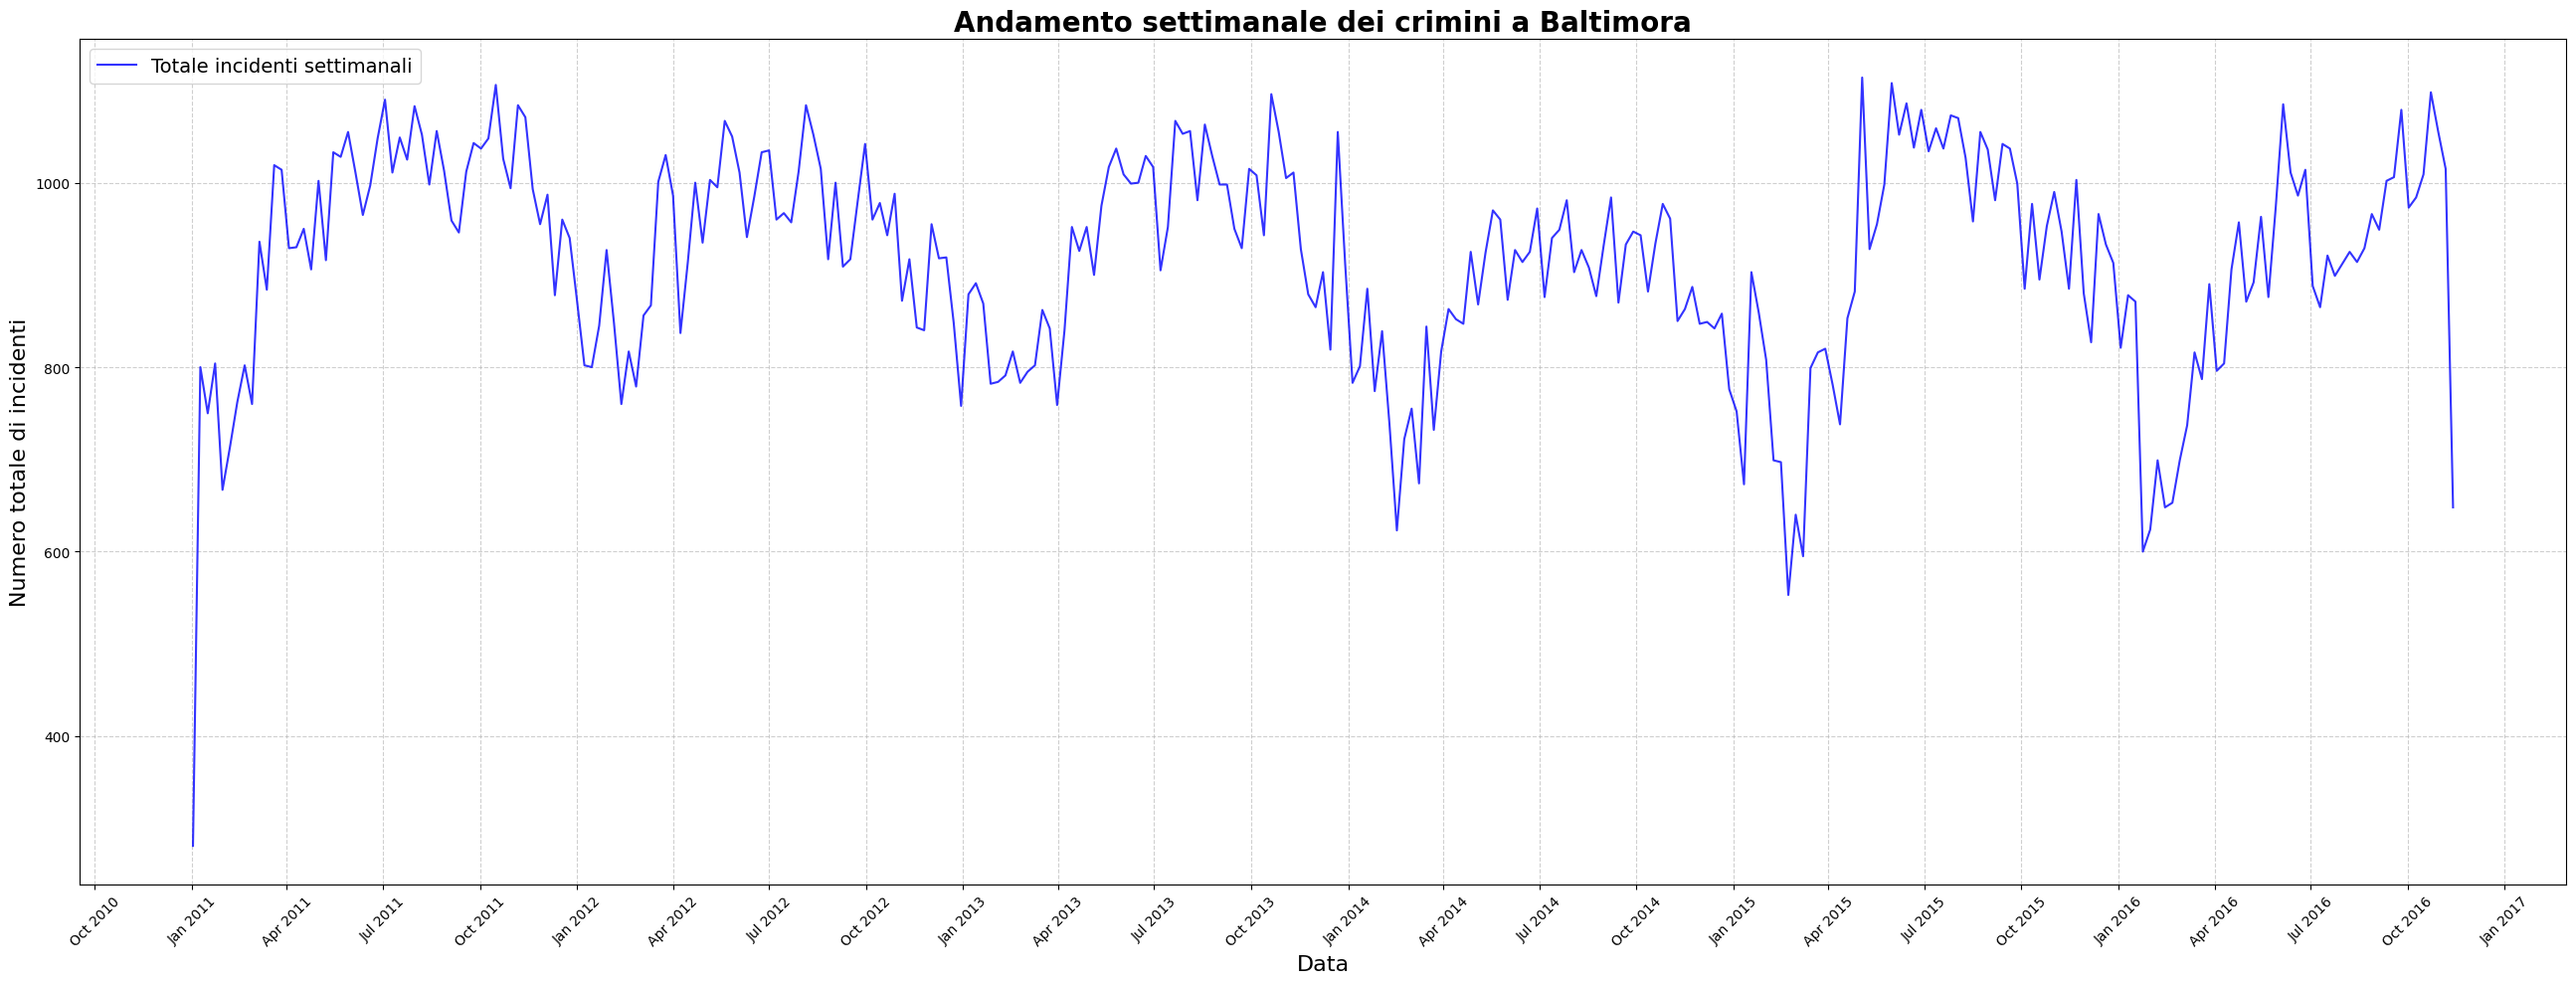

In [28]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.figure(figsize=(26, 10))
plt.plot(
    crime_time_series['DateTime'],
    crime_time_series['Total Incidents'],
    label='Totale incidenti settimanali',
    alpha=0.8,
    linewidth=1.5,
    color='blue'
)

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45)
plt.title('Andamento settimanale dei crimini a Baltimora', fontsize=20, fontweight='bold')
plt.xlabel('Data', fontsize=16)
plt.ylabel('Numero totale di incidenti', fontsize=16)
plt.legend(fontsize=14, loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Osservando il grafico dell'**andamento settimanale dei crimini a Baltimora**, si possono notare alcune caratteristiche che suggeriscono che la serie **non è stazionaria**:

1. **Media non costante nel tempo**
   - Ci sono periodi in cui il numero totale di incidenti settimanali è mediamente più alto (ad esempio tra il 2011 ed il 2013, di nuovo intorno al 2015-2016).
   - Altri periodi mostrano una diminuzione visibile (ad esempio inizio 2015 ed inizio 2016).
   - Questo indica che la media varia nel tempo.

2. **Varianza non costante nel tempo**
   - L'ampiezza delle fluttuazione ("dispersione" dei valori) non è omogenea: in certi intervalli la variabilità sembra più elevata, mentre in altri le oscillazioni sono più contenute.
   - Anche la varianza, quindi, sembra cambiare nel tempo.

3. **Possibile stagionalità**
   - Il grafico mostra ciclicità annuale o semestrale: periodi ricorrenti in cui i crimini aumentano o diminuiscono, compatibili con **pattern stagionali** (ad esempio aumenti estivi o cali invernali).
   - Questo tipo di oscillazione periodica è tipico di una serie **non stazionaria** con componente stagionale.

4. **Valori più contenuti in certi intervalli**
   - Si notano cali marcati in corrispondenza di alcuni anni (ad esempio inizio 2015 e 2016), forse legati a fattori specifici (politiche di sicurezza, eventi eccezionali, cambiamenti nei dati).

In sintesi, la serie sembra **non essere stazionaria**, poiché **media e varianza variano nel tempo** e sono presenti **elementi di stagionalità**. Per analisi predittive è necessario **stazionarla** tramite differenziazione o rimozione della stagionalità.

Per effettuare un'analisi più approfondita, si decomporrà la serie nelle sue componenti stagionali, di trend e residuali.


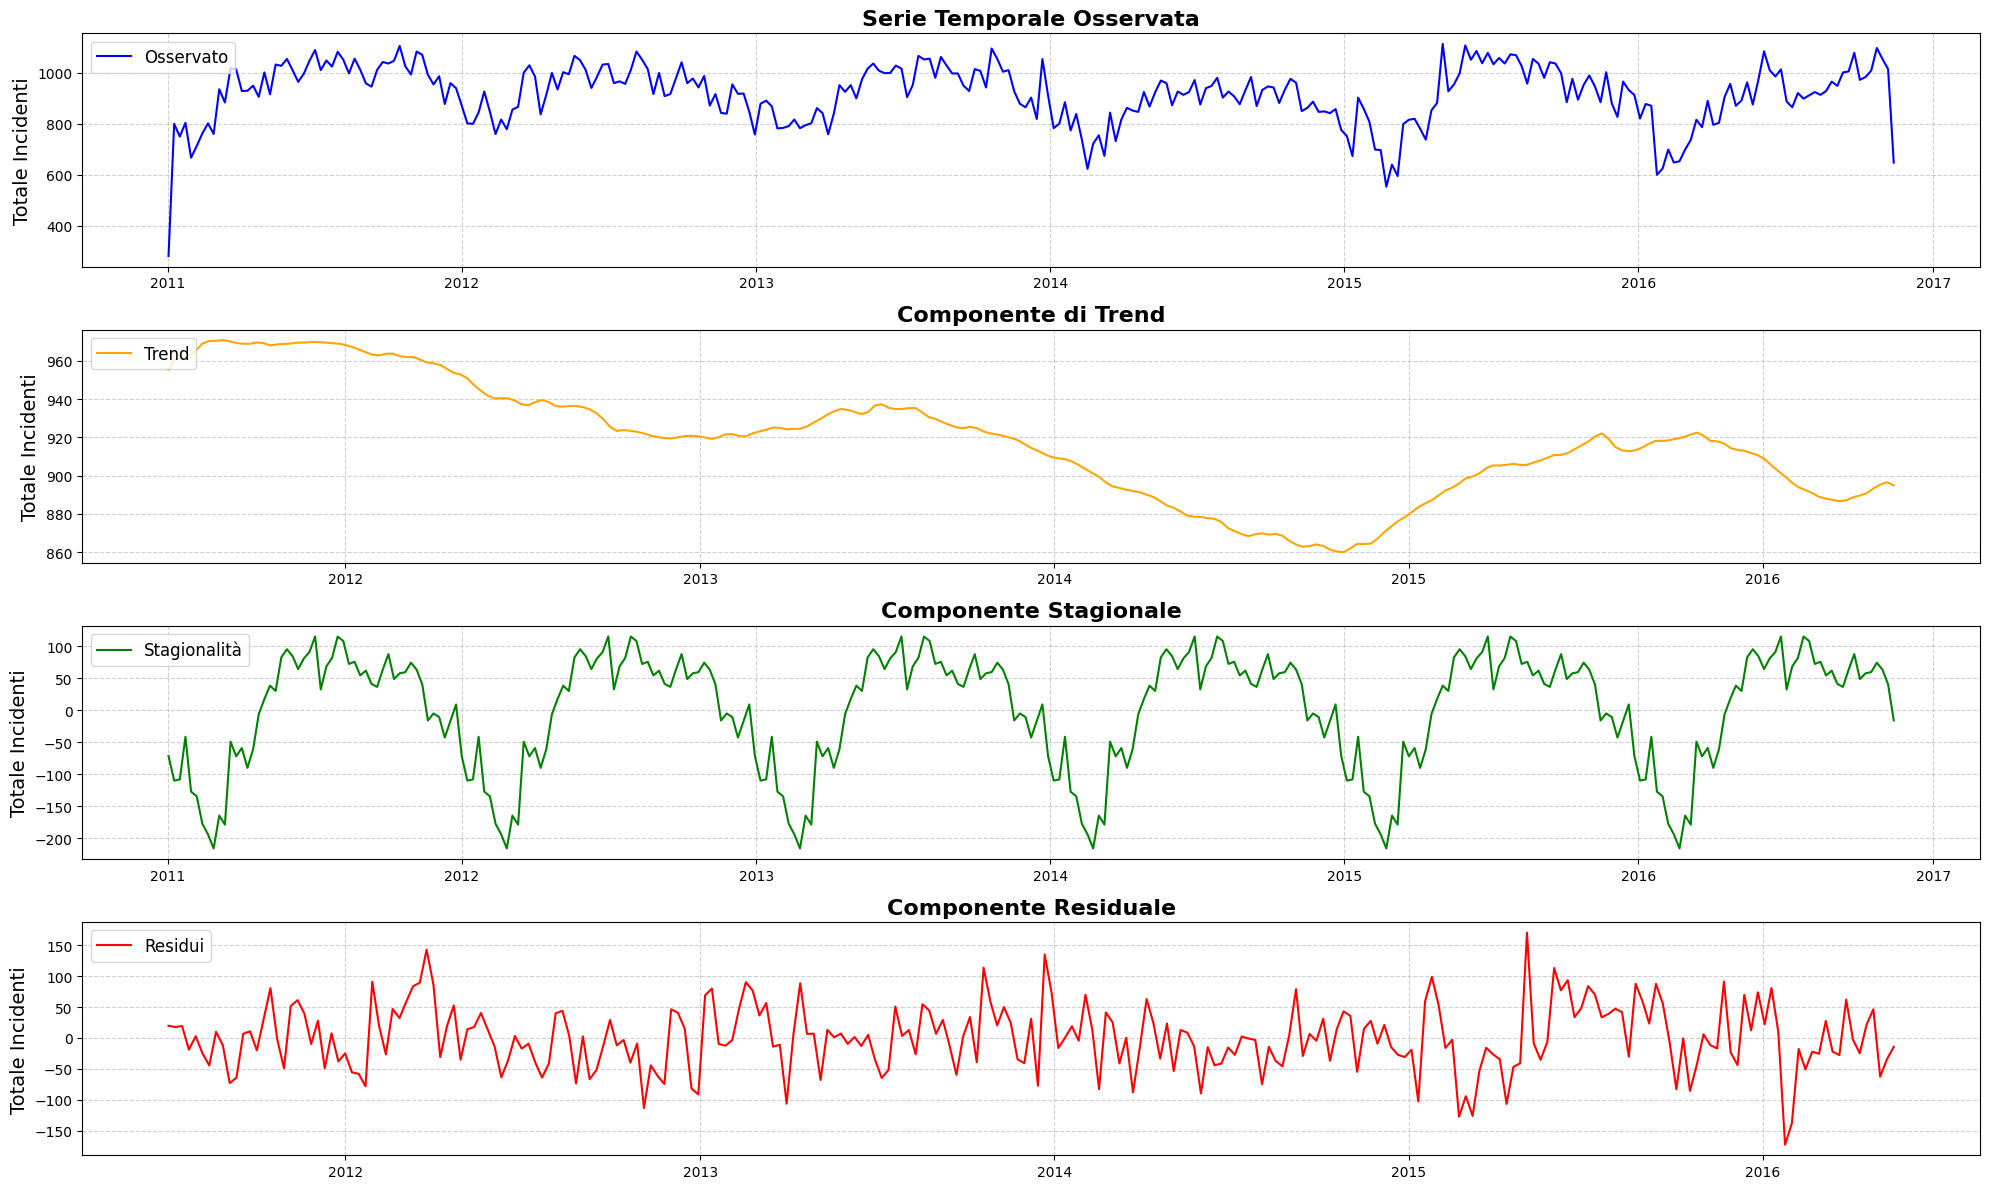

In [29]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Decomposizione della serie temporale
decomposition = seasonal_decompose(
    crime_time_series.set_index('DateTime')['Total Incidents'], 
    model='additive', 
    period=52
)
plt.figure(figsize=(20, 12))

# Osservato
plt.subplot(411)
plt.plot(decomposition.observed, label='Osservato', color='blue', linewidth=1.5)
plt.title('Serie Temporale Osservata', fontsize=16, fontweight='bold')
plt.ylabel('Totale Incidenti', fontsize=14)
plt.legend(loc='upper left', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

# Trend
plt.subplot(412)
plt.plot(decomposition.trend, label='Trend', color='orange', linewidth=1.5)
plt.title('Componente di Trend', fontsize=16, fontweight='bold')
plt.ylabel('Totale Incidenti', fontsize=14)
plt.legend(loc='upper left', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

# Stagionalità
plt.subplot(413)
plt.plot(decomposition.seasonal, label='Stagionalità', color='green', linewidth=1.5)
plt.title('Componente Stagionale', fontsize=16, fontweight='bold')
plt.ylabel('Totale Incidenti', fontsize=14)
plt.legend(loc='upper left', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

# Residui
plt.subplot(414)
plt.plot(decomposition.resid, label='Residui', color='red', linewidth=1.5)
plt.title('Componente Residuale', fontsize=16, fontweight='bold')
plt.ylabel('Totale Incidenti', fontsize=14)
plt.legend(loc='upper left', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

1. **Componente di Trend**
   - Il trend mostra **una diminuzione graduale dal 2011 al 2014**, seguita da **una lieva risalita tra il 2015 e il 2016**.
   - Questo suggerisce che, nel lungo periodo, il **numero medio di crimini settimanali tende a calare leggermente**, ma con una ripresa negli ultimi anni del campione.
   - Quindi, **la media non è costante nel tempo**, confermando che la serie non è stazionaria in livello.

2. **Componente Stagionale**
   - Si osserva **una chiara periodicità annuale**, con oscillazioni regolari e simmetriche intorno allo zero.
   - La stagionalità è **molto marcata e stabile nel tempo**, indicando che i crimini tendono ad aumentare e diminuire in determinati periodi dell'anno (ad esempio più incidenti nei mesi estivi, meno in quelli invernali).
   - Questa regolarità suggerisce una **stagionalità fissa e ripetitiva**, il che è tipico di fenomeni sociali o ambienti influenzati da condizioni ricorrenti.

3. **Componente Residuale**
   - I residui oscillano intorno allo zero senza una struttura evidente, ma **non appaiono completamente bianchi**: in certi periodi (ad esempio 2015) sembrano più disperi o con outlier.
   - Ciò indica che **parte della varianza non è spiegata** né dal trend né dalla stagionalità, ma non emergono pattern sistematici forti.
   - La varianza dei residui appare **piuttosto costante nel tempo**, un buon segno per modellazione successiva.

In sintesi, la serie **non è stazionaria in livello**, perché presenta **trend e stagionalità**. Dopo la rimozione del trend e della stagionalità o una differenziazione stagionale, i **residui potrebbero risultare stazionari** e quindi adatti a modelli successivi.

Per confermare l'ipotesi effettuiamo l'**ADF Test (Augmented Dickey-Fuller)** e misuriamo il **p-value**, che per serie stazionarie dovrebbe essere inferiore alla soglia di 0.05.

In [30]:
from statsmodels.tsa.stattools import adfuller

# Test di stazionarietà ADF
adf_test = adfuller(crime_time_series['Total Incidents'])

adf_results = pd.Series({"ADF Test Statistic": adf_test[0],
                         "p-value": adf_test[1],
                         "Used Lag": adf_test[2],
                         "Number of Observations": adf_test[3],
                         "Critical Value (1%)": adf_test[4]['1%'],
                         "Critical Value (5%)": adf_test[4]['5%'],
                         "Critical Value (10%)": adf_test[4]['10%']})

print("\n=== Risultati del test di stazionarietà ADF ===")
adf_results


=== Risultati del test di stazionarietà ADF ===


ADF Test Statistic         -4.303567
p-value                     0.000438
Used Lag                    9.000000
Number of Observations    297.000000
Critical Value (1%)        -3.452561
Critical Value (5%)        -2.871321
Critical Value (10%)       -2.571982
dtype: float64

In contrapposizione all'analisi effettuata, osservando i valori dell'ADF Test si può **rifiutare l'ipotesi nulla** con elevata confidenza (anche al livello dell'1%) e concludere che la serie è **stazionaria**. Tuttavia, ci sono alcune considerazioni da tenere in mente:
- **Statisticamente**, l'ADF dice che la serie può essere trattata come stazionaria.
- **Visivamente**, però, rimangono segnali di **trend e stagionalità**, quindi per l'utilizzo di modelli come ARIMA/SARIMA è comunque consigliabile una **differenziazione (o rimozione della stagionalità)** per sicurezza.

Quindi, si procederà con due approcci di differenziazione:
- **Semplice**: per rimuovere il trend.
- **Stagionale**: per rimuovere pattern annuali o periodici.

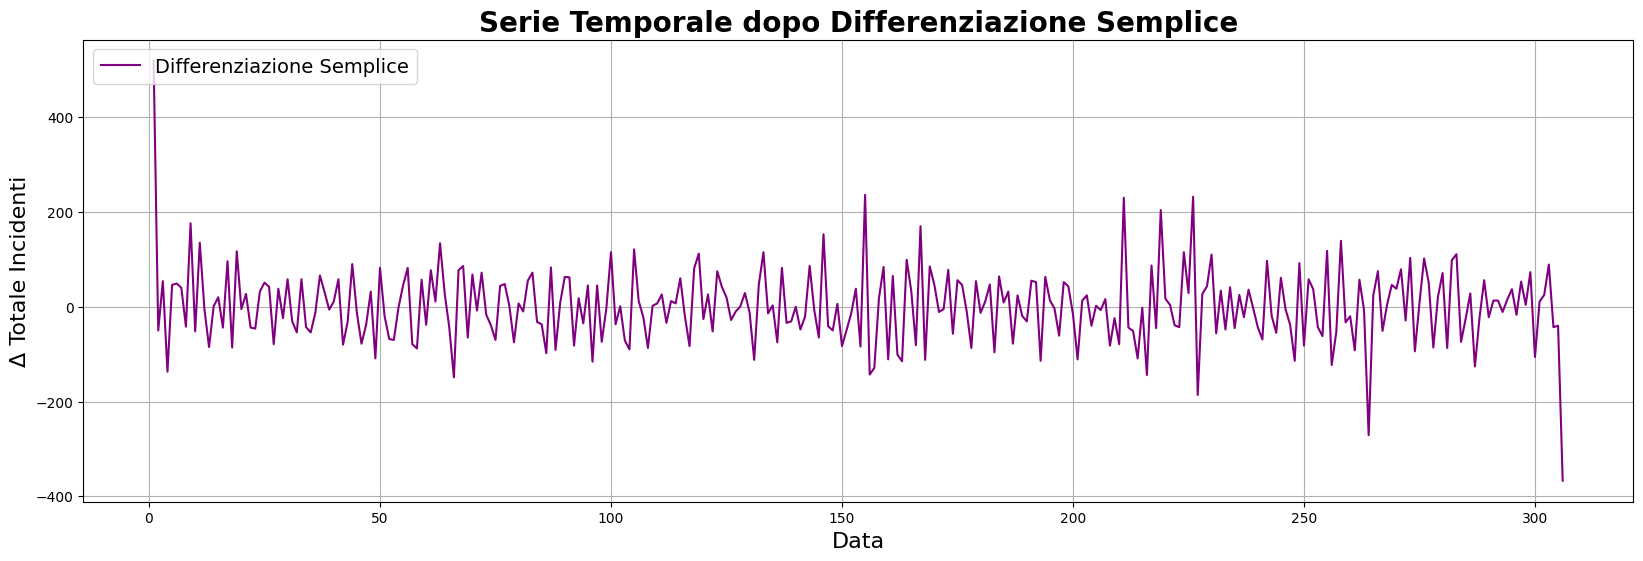

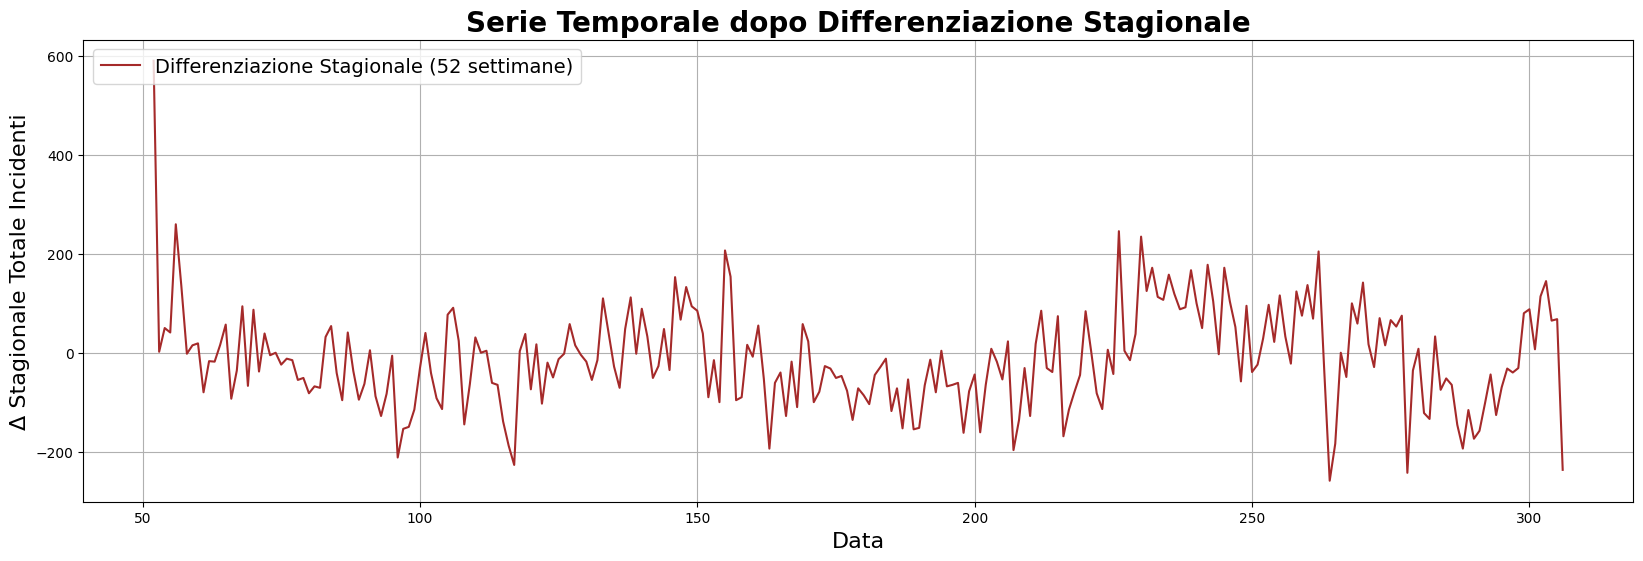


=== Risultati del test di stazionarietà ADF sulla serie differenziata semplice ===
ADF Test Statistic       -7.476872e+00
p-value                   4.887433e-11
Used Lag                  5.000000e+00
Number of Observations    3.000000e+02
Critical Value (1%)      -3.452337e+00
Critical Value (5%)      -2.871223e+00
Critical Value (10%)     -2.571929e+00
dtype: float64

=== Risultati del test di stazionarietà ADF sulla serie differenziata stagionale ===
ADF Test Statistic         -4.166292
p-value                     0.000751
Used Lag                    5.000000
Number of Observations    249.000000
Critical Value (1%)        -3.456888
Critical Value (5%)        -2.873219
Critical Value (10%)       -2.572994
dtype: float64


In [32]:
from statsmodels.tsa.stattools import adfuller

# Differenziazione semplice
crime_diff = crime_time_series['Total Incidents'].diff().dropna()

# Differenziazione stagionale (period=52 settimane)
crime_seasonal_diff = crime_time_series['Total Incidents'].diff(52).dropna()

# Grafico della differenziazione semplice
plt.figure(figsize=(20, 6))
plt.plot(crime_diff, label='Differenziazione Semplice', color='purple', linewidth=1.5)
plt.title('Serie Temporale dopo Differenziazione Semplice', fontsize=20, fontweight='bold')
plt.xlabel('Data', fontsize=16)
plt.ylabel('Δ Totale Incidenti', fontsize=16)
plt.legend(fontsize=14, loc='upper left')
plt.grid(True)
plt.show()

# Grafico della differenziazione stagionale
plt.figure(figsize=(20, 6))
plt.plot(crime_seasonal_diff, label='Differenziazione Stagionale (52 settimane)', color='brown', linewidth=1.5)
plt.title('Serie Temporale dopo Differenziazione Stagionale', fontsize=20, fontweight='bold')
plt.xlabel('Data', fontsize=16)
plt.ylabel('Δ Stagionale Totale Incidenti', fontsize=16)
plt.legend(fontsize=14, loc='upper left')
plt.grid(True)
plt.show()

# Test di stazionarietà ADF sulla serie differenziata
adf_test_diff = adfuller(crime_diff)
adf_test_seasonal_diff = adfuller(crime_seasonal_diff)
adf_results_diff = pd.Series({"ADF Test Statistic": adf_test_diff[0],
                         "p-value": adf_test_diff[1],
                         "Used Lag": adf_test_diff[2],
                         "Number of Observations": adf_test_diff[3],
                         "Critical Value (1%)": adf_test_diff[4]['1%'],
                         "Critical Value (5%)": adf_test_diff[4]['5%'],
                         "Critical Value (10%)": adf_test_diff[4]['10%']})

adf_results_seasonal_diff = pd.Series({"ADF Test Statistic": adf_test_seasonal_diff[0],
                         "p-value": adf_test_seasonal_diff[1],
                         "Used Lag": adf_test_seasonal_diff[2],
                         "Number of Observations": adf_test_seasonal_diff[3],
                         "Critical Value (1%)": adf_test_seasonal_diff[4]['1%'],
                         "Critical Value (5%)": adf_test_seasonal_diff[4]['5%'],
                         "Critical Value (10%)": adf_test_seasonal_diff[4]['10%']})
print("\n=== Risultati del test di stazionarietà ADF sulla serie differenziata semplice ===")
print(adf_results_diff)
print("\n=== Risultati del test di stazionarietà ADF sulla serie differenziata stagionale ===")
print(adf_results_seasonal_diff)

1. **Differenziazione semplice**
   - La statistica ADF (-7.48) è **molto più piccola** del valore critico al 1% (-3.45).
   - Il p-value è **praticamente zero**.
   - Conclusione: la serie differenziata semplice è **fortemente stazionaria**, il trend è stato completamente rimosso e ora la media e la varianza sono costanti nel tempo.

2. **Differenziazione stagionale (lag = 52 settimane)**
   - Anche qui la statistica ADF è **inferiore** al valore critico al 1% (-3.46).
   - Il p-value è ancora **molto basso** (<0.01).
   - Conclusione: la serie differenziata stagionale è anch'essa **stazionaria**, ma l'effetto è **meno marcato** rispetto alla differenziazione semplice.

In sintesi, la **differenziazione semplice** ha reso la serie fortemente stazionaria eliminando il trend principale, mentre la **differenziazione stagionale** ha rimosso le oscillazioni annuali, ma non riduce tanto la dipendenza come la prima. Entrambe le serie, quindi, risultano **statisticamente stazionarie**, ma per motivi diversi.

Per modelli come **SARIMA**, dove è utile catturare sia trend che stagionalità, la soluzione migliore è **applicare entrambe le differenziazioni**, verificando di nuovo la stazionarietà e la stabilità visiva, dato che, in genere, la doppia differenziazione fornisce una serie finale stazionaria in media e varianza, pronta per il fitting di un modello ARIMA/SARIMA.

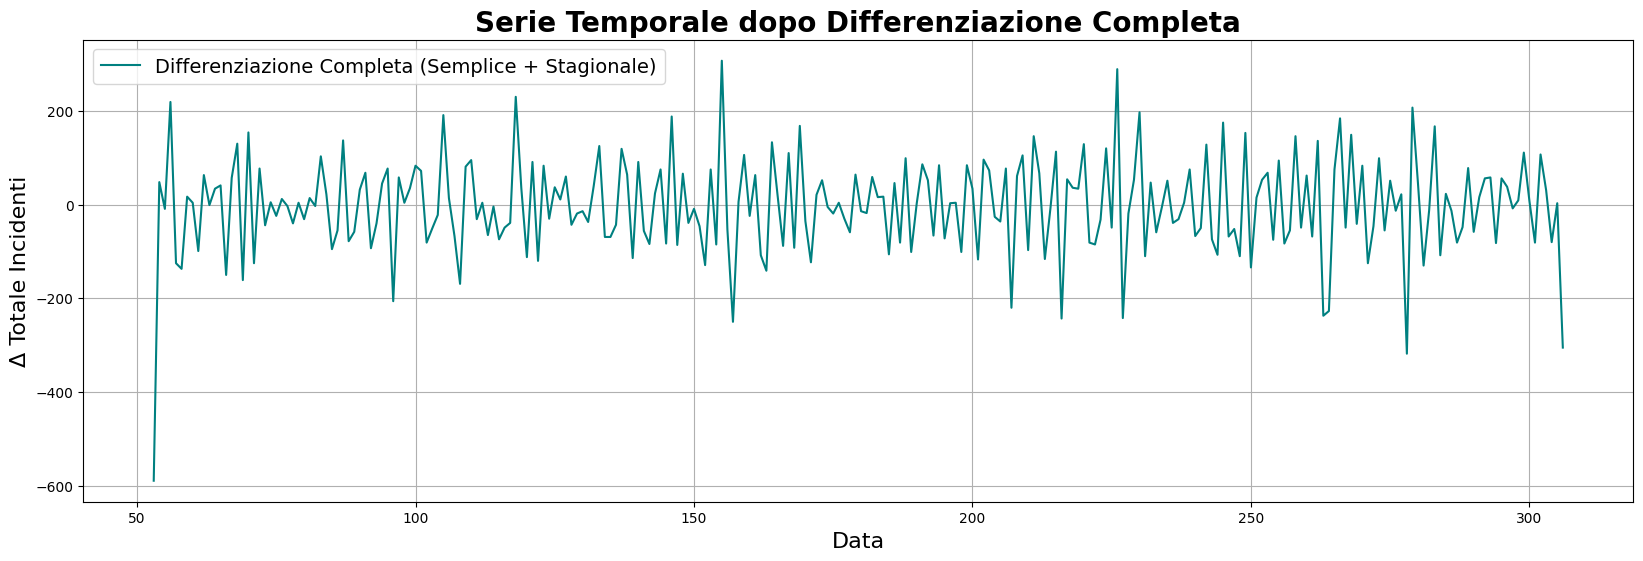

In [33]:
# Differenziazione completa (semplice + stagionale)
crime_diff_full = crime_time_series['Total Incidents'].diff().diff(52).dropna()

# Grafico della differenziazione completa
plt.figure(figsize=(20, 6))
plt.plot(crime_diff_full, label='Differenziazione Completa (Semplice + Stagionale)', color='teal', linewidth=1.5)
plt.title('Serie Temporale dopo Differenziazione Completa', fontsize=20, fontweight='bold')
plt.xlabel('Data', fontsize=16)
plt.ylabel('Δ Totale Incidenti', fontsize=16)
plt.legend(fontsize=14, loc='upper left')
plt.grid(True)
plt.show()

Nel grafico possiamo osservare che la serie differenziata completa (semplice + stagionale) oscilla chiaramente **intorno allo zero**, senza trend evidente. Inoltre, la varianza è **piuttosto costante** nel tempo (non aumenta né diminuisce). Infine, non si osservano più pattern stagionali regolari (le oscillazioni sono irregolari).

In [34]:
# Test di stazionarietà ADF sulla serie completamente differenziata
adf_test_diff_full = adfuller(crime_diff_full)

# Risultati del test ADF
adf_results_diff_full = pd.Series({"ADF Test Statistic": adf_test_diff_full[0],
                         "p-value": adf_test_diff_full[1],
                         "Used Lag": adf_test_diff_full[2],
                         "Number of Observations": adf_test_diff_full[3],
                         "Critical Value (1%)": adf_test_diff_full[4]['1%'],
                         "Critical Value (5%)": adf_test_diff_full[4]['5%'],
                         "Critical Value (10%)": adf_test_diff_full[4]['10%']})

print("\n=== Risultati del test di stazionarietà ADF sulla serie completamente differenziata ===")
print(adf_results_diff_full)


=== Risultati del test di stazionarietà ADF sulla serie completamente differenziata ===
ADF Test Statistic       -1.157592e+01
p-value                   3.022940e-21
Used Lag                  4.000000e+00
Number of Observations    2.490000e+02
Critical Value (1%)      -3.456888e+00
Critical Value (5%)      -2.873219e+00
Critical Value (10%)     -2.572994e+00
dtype: float64


Osservando i risultati del test di stazionarietà ADF applicato alla serie differenzata completa, si può concludere che la serie è **pienamente stazionaria**. Si può quindi procedere con l'analisi dei **correlogrammi ACF e PACF** per stimare i parametri (p, d, q) del modello SARIMA.

### Analisi dei correlogrammi

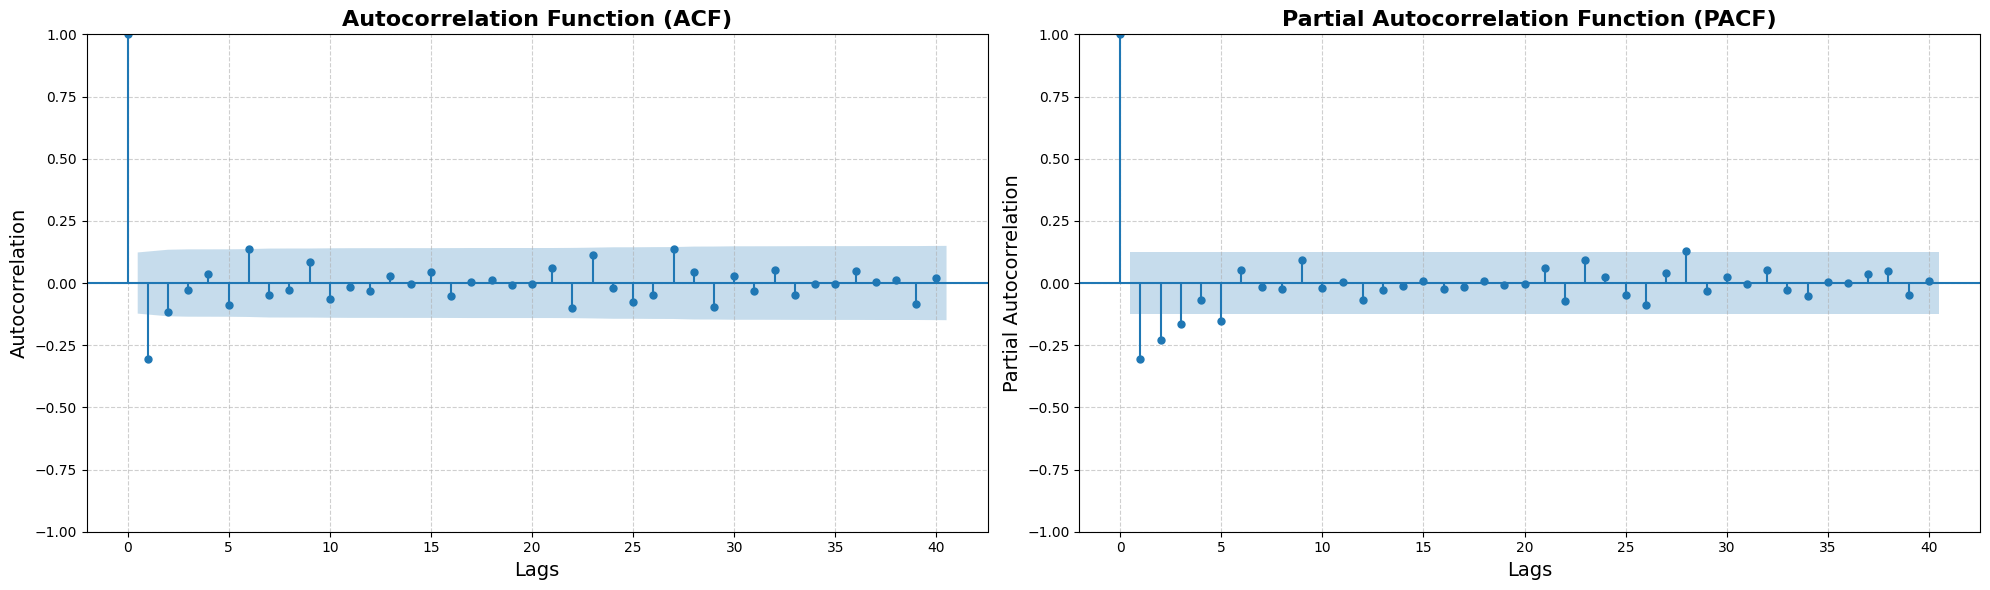

In [37]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Creazione dei grafici ACF e PACF
fig, axes = plt.subplots(1, 2, figsize=(20, 6), dpi = 100)

# Grafico ACF
plot_acf(crime_diff_full, lags=40, ax=axes[0])
axes[0].set_title('Autocorrelation Function (ACF)', fontsize=16, fontweight='bold')
axes[0].set_xlabel('Lags', fontsize=14)
axes[0].set_ylabel('Autocorrelation', fontsize=14)
axes[0].grid(True, linestyle='--', alpha=0.6)

# Grafico PACF
plot_pacf(crime_diff_full, lags=40, ax=axes[1])
axes[1].set_title('Partial Autocorrelation Function (PACF)', fontsize=16, fontweight='bold')
axes[1].set_xlabel('Lags', fontsize=14)
axes[1].set_ylabel('Partial Autocorrelation', fontsize=14)
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()